In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


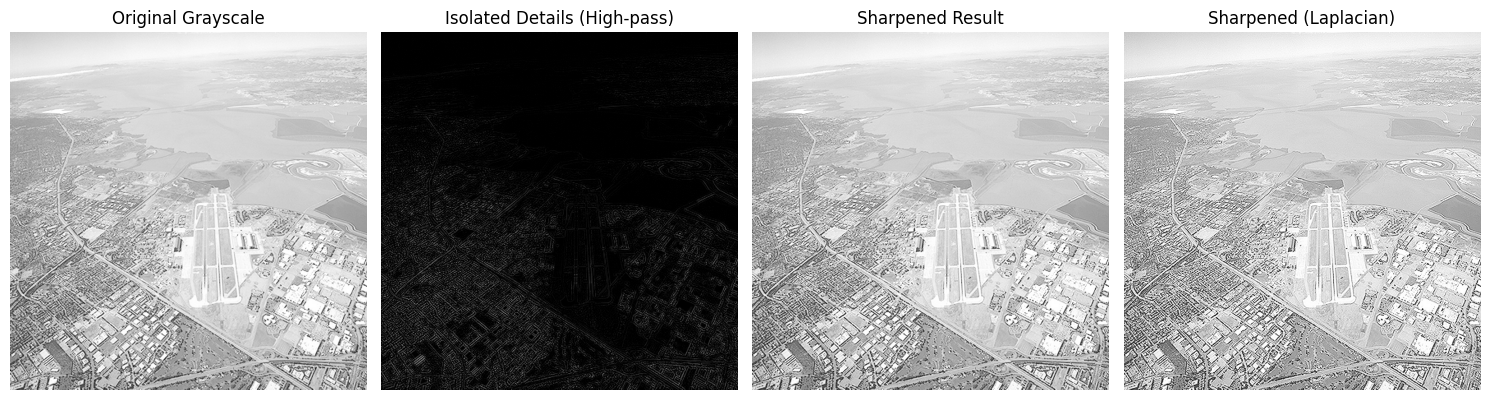

In [ ]:

img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

# Blur the image (Low-pass filter)---- This removes the sharp details
blurred = cv2.GaussianBlur(img, (5, 5), 1.0)
details = cv2.subtract(img, blurred) ## Unsharp Masking ---- Details = Original - Blurred

# Sharpening - Formula: Sharpened = Original + k * (Original - Blurred)
# k = 1.0 is standard; k > 1.0 is high-boost filtering
sharpened = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)

# Else Apply Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F)
sharpened_laplacian = img - 0.7 * laplacian
sharpened_laplacian = np.clip(sharpened_laplacian, 0, 255).astype(np.uint8)

cv2.imwrite('ques9/sharpened_laplacian.png', sharpened_laplacian)

# --- Visualization ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(details, cmap='gray')
plt.title("Isolated Details (High-pass)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Result")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sharpened_laplacian, cmap='gray')
plt.title("Sharpened (Laplacian)")
plt.axis('off')

plt.tight_layout()
plt.show()